In [1]:
import csv

data = [
    [18,1,0,0,120,7.8,1],
    [22,0,1,0,90,6.5,1],
    [25,0,0,1,40,5.9,0],
    [30,1,0,0,150,8.2,1],
    [35,0,1,0,30,5.5,0],
    [40,0,0,1,110,7.2,1],
    [28,1,0,0,20,4.8,0],
    [19,0,1,0,140,7.9,1],
    [45,0,0,1,50,6.0,0],
    [33,1,0,0,160,8.5,1],
    [27,0,1,0,60,6.2,0],
    [21,1,0,0,130,7.6,1],
    [38,0,0,1,45,5.7,0],
    [24,0,1,0,100,7.0,1],
    [50,0,0,1,25,4.9,0],
    [29,1,0,0,145,8.1,1],
    [34,0,1,0,35,5.6,0],
    [26,0,0,1,120,7.4,1],
    [41,1,0,0,15,4.5,0],
    [23,0,1,0,135,7.8,1]
]

headers = ['Age','Genre_Action','Genre_Comedy','Genre_Drama','Watch_Time_Min','IMDb_Rating','Liked']

with open('movie_data.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(headers)
    writer.writerows(data)

In [2]:
import pandas as pd  # pandas is used to work with tabular data

# Load the dataset
df = pd.read_csv("movie_preferences.csv")

# Show first 5 rows
df.head()


,Age,Genre_Action,Genre_Comedy,Genre_Drama,Watch_Time_Min,IMDb_Rating,Liked
0,18,1,0,0,120,7.8,1
1,22,0,1,0,90,6.5,1
2,25,0,0,1,40,5.9,0
3,30,1,0,0,150,8.2,1
4,35,0,1,0,30,5.5,0


In [3]:
# Check dataset shape (rows, columns)
df.shape  # number of samples and features


(20, 7)

In [4]:
# Check column names
df.columns


Index(['Age', 'Genre_Action', 'Genre_Comedy', 'Genre_Drama', 'Watch_Time_Min',
       'IMDb_Rating', 'Liked'],
      dtype='object')

In [5]:
# Check data types and null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             20 non-null     int64  
 1   Genre_Action    20 non-null     int64  
 2   Genre_Comedy    20 non-null     int64  
 3   Genre_Drama     20 non-null     int64  
 4   Watch_Time_Min  20 non-null     int64  
 5   IMDb_Rating     20 non-null     float64
 6   Liked           20 non-null     int64  
dtypes: float64(1), int64(6)
memory usage: 1.2 KB


In [6]:
df["Liked"].value_counts()


1    11
0     9
Name: Liked, dtype: int64

In [7]:
# Features (input)
X = df.drop("Liked", axis=1)  # remove target column

# Target (output)
y = df["Liked"]


In [9]:
from sklearn.preprocessing import StandardScaler  # used for scaling data

# Create scaler object
scaler = StandardScaler()

# Fit scaler on X and transform
X_scaled = scaler.fit_transform(X)


In [10]:
from sklearn.model_selection import train_test_split  # split data

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.25,      # 25% test data
    random_state=42      # reproducibility
)


In [11]:
from sklearn.neighbors import KNeighborsClassifier  # KNN algorithm

# Create KNN model with K = 5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [12]:
# Check accuracy
accuracy = knn.score(X_test, y_test)
accuracy


1.0

In [13]:
new_movie = [[
    26,   # Age
    1,    # Action
    0,    # Comedy
    0,    # Drama
    130,  # Watch time
    7.9   # IMDb rating
]]

# Scale new input
new_movie_scaled = scaler.transform(new_movie)

# Predict
prediction = knn.predict(new_movie_scaled)

prediction


C:\Users\Swaraj\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [14]:
# Create new movie as DataFrame
new_movie_df = pd.DataFrame([{
    "Age": 26,
    "Genre_Action": 1,
    "Genre_Comedy": 0,
    "Genre_Drama": 0,
    "Watch_Time_Min": 130,
    "IMDb_Rating": 7.9
}])

# Scale
new_movie_scaled = scaler.transform(new_movie_df)

# Predict
prediction = knn.predict(new_movie_scaled)

prediction


array([1], dtype=int64)

In [15]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)
    accuracies.append(acc)


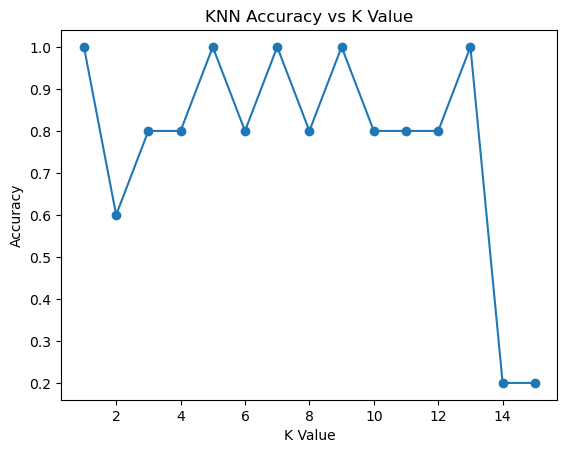

In [16]:
plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K Value")
plt.show()


In [17]:
best_k = k_values[accuracies.index(max(accuracies))]
best_k


1

In [18]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=1)

In [19]:
prediction = knn_final.predict(new_movie_scaled)
prediction


array([1], dtype=int64)